# Итоговый проект — Вариант ML-04
# Классификатор категорий новостей

**Модуль 07 · AI HUB · Трек А (ML-сервис)**

---

## Задача

Построить сервис автоматической классификации новостной статьи по тематической категории.

**Датасет:** 20 Newsgroups — встроен в scikit-learn, **ничего скачивать не нужно**:

```python
from sklearn.datasets import fetch_20newsgroups
```

18 846 документов, 20 категорий (tech, religion, sports, politics, sci…). Для этого варианта рекомендуется начать с 6 категорий:

```python
categories = [
    'rec.sport.hockey', 'rec.sport.baseball',
    'sci.space', 'sci.med',
    'comp.graphics', 'talk.politics.guns',
]
```

**Стек:** TF-IDF (`stop_words='english'`) → CatBoost multi-class → MLflow → FastAPI `/classify` → Docker → CI/CD

**Целевые метрики:** Accuracy ≥ 0.80 (6 кл.) · F1-macro ≥ 0.80

---

## Задание 1 — Загрузка данных

1. Загрузите train и test через `fetch_20newsgroups` с параметром `remove=('headers', 'footers', 'quotes')`
2. Выберите 6 категорий (или все 20)
3. Создайте `pd.DataFrame` с колонками `text` и `category`
4. Выведите количество документов на класс

> ⚠️ `remove=('headers', 'footers', 'quotes')` — **обязателен**. Без него модель запоминает email-адреса авторов вместо контента, и accuracy искусственно ~99%. Это data leakage.

In [ ]:
!pip install mlflow catboost
from sklearn.datasets import fetch_20newsgroups
from datasets import load_dataset
import pandas as pd

categories = [
    'rec.sport.hockey', 'rec.sport.baseball',
    'sci.space', 'sci.med',
    'comp.graphics', 'talk.politics.guns',
]

train_data = fetch_20newsgroups(
    subset = 'train',
    categories = categories,
    remove = ('headers', 'footers', 'quotes'),
    shuffle = True
)

test_data = fetch_20newsgroups(
    subset = 'test',
    categories = categories,
    shuffle=True
)

df_train = pd.DataFrame({'text': train_data.data, 'category': train_data.target})
df_test = pd.DataFrame({'text': test_data.data, "category": test_data.target})

df_all = pd.concat([df_train, df_test], ignore_index=True)

print("\nКоличество документов на класс (все данные):")
print(df_all['category'].value_counts().sort_index())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/13

---

## Задание 2 — EDA

1. Горизонтальный bar chart: количество документов на класс (проверьте сбалансированность)
2. Гистограмма длин текстов (слов)
3. Топ-10 наиболее характерных слов для 2–3 выбранных категорий

Запишите: есть ли ожидаемые слова-маркеры категорий?

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Данные загружены. Количество документов: 5853


/tmp/ipykernel_3048/3670756639.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts_df, y='category', x='count', palette='viridis')


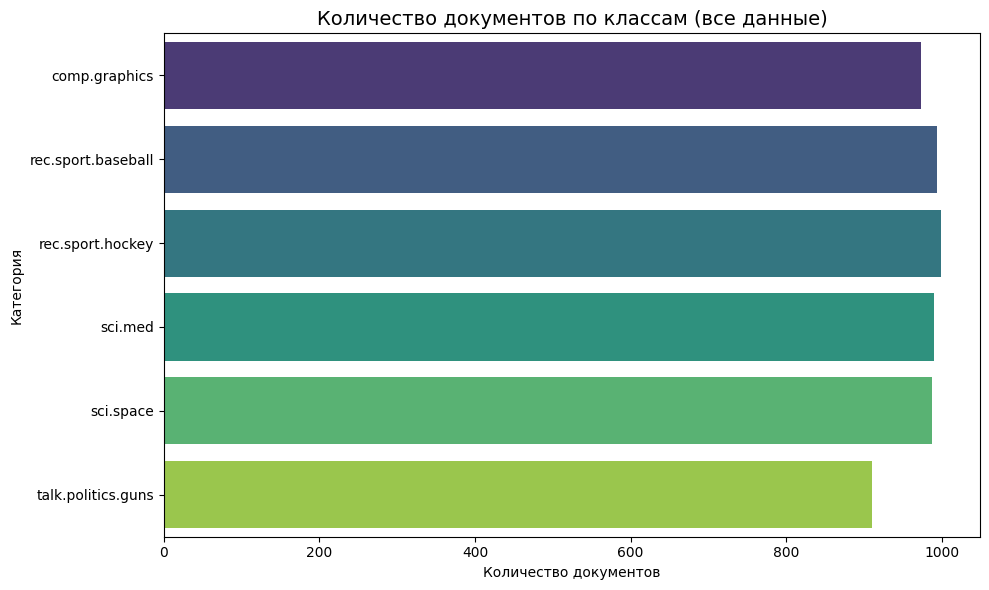


=== Распределение по классам ===
category
0    973
1    994
2    999
3    990
4    987
5    910
Name: count, dtype: int64
Минимум: 910, максимум: 999
Разброс: 89


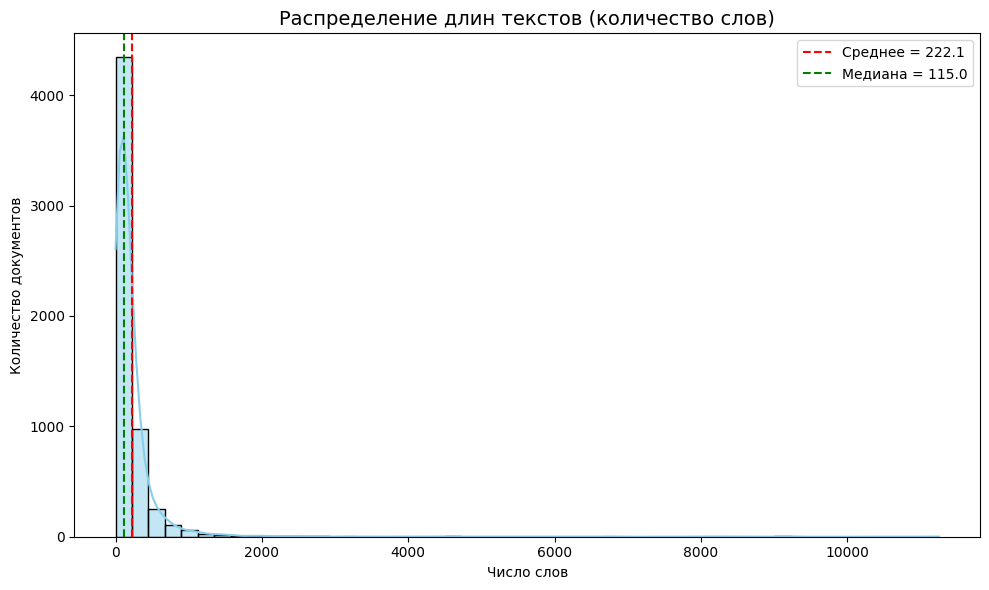


=== Статистика длин текстов ===
count     5853.000000
mean       222.104562
std        516.844474
min          0.000000
25%         57.000000
50%        115.000000
75%        231.000000
max      11251.000000
Name: word_count, dtype: float64

=== Топ-10 наиболее характерных слов для выбранных категорий ===

Категория: rec.sport.hockey
  hockey: 3198.90
  game: 2286.37
  nhl: 1766.64
  team: 1676.98
  25: 1564.23
  55: 1478.46
  pit: 1289.53
  det: 1284.63
  play: 1224.77
  la: 1224.16

Категория: sci.space
  space: 6662.36
  nasa: 2191.31
  launch: 1948.87
  earth: 1901.45
  shuttle: 1851.43
  orbit: 1716.68
  mission: 1565.56
  moon: 1380.97
  solar: 1329.90
  spacecraft: 1291.68

Категория: talk.politics.guns
  gun: 4870.21
  fbi: 2498.24
  guns: 2483.68
  fire: 1875.50
  firearms: 1591.54
  batf: 1529.81
  government: 1467.01
  weapons: 1440.92
  atf: 1399.45
  koresh: 1346.80

ВЫВОДЫ:

В каждой из трёх выбранных категорий в топ-10 входят очевидные тематические термины:

- rec.sport

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

nltk.download('stopwords')
stop_words_set = set(stopwords.words('english'))
stop_words_list = list(stop_words_set)

category_names = train_data.target_names

print("Данные загружены. Количество документов:", len(df_all))

class_counts = df_all['category'].value_counts().sort_index()

counts_df = pd.DataFrame({
    'category': [category_names[i] for i in class_counts.index],
    'count': class_counts.values
})

plt.figure(figsize=(10, 6))
sns.barplot(data=counts_df, y='category', x='count', palette='viridis')
plt.title('Количество документов по классам (все данные)', fontsize=14)
plt.xlabel('Количество документов')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

print("\n=== Распределение по классам ===")
print(class_counts)
print(f"Минимум: {class_counts.min()}, максимум: {class_counts.max()}")
print(f"Разброс: {class_counts.max() - class_counts.min()}")

def count_words(text):
    return len(text.split())

df_all['word_count'] = df_all['text'].apply(count_words)

plt.figure(figsize=(10, 6))
sns.histplot(df_all['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Распределение длин текстов (количество слов)', fontsize=14)
plt.xlabel('Число слов')
plt.ylabel('Количество документов')
plt.axvline(df_all['word_count'].mean(), color='red', linestyle='--',
            label=f'Среднее = {df_all["word_count"].mean():.1f}')
plt.axvline(df_all['word_count'].median(), color='green', linestyle='--',
            label=f'Медиана = {df_all["word_count"].median():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Статистика длин текстов ===")
print(df_all['word_count'].describe())

selected_categories = ['rec.sport.hockey', 'sci.space', 'talk.politics.guns']
selected_indices = [category_names.index(cat) for cat in selected_categories]

vectorizer = CountVectorizer(stop_words=stop_words_list, max_features=10000)
X = vectorizer.fit_transform(df_all['text'])
feature_names = vectorizer.get_feature_names_out()

print("\n=== Топ-10 наиболее характерных слов для выбранных категорий ===")

for cat_name, cat_idx in zip(selected_categories, selected_indices):
    y_bin = (df_all['category'] == cat_idx).astype(int)
    chi2_scores, p_values = chi2(X, y_bin)
    top_indices = np.argsort(chi2_scores)[-10:][::-1]
    top_words = feature_names[top_indices]
    top_scores = chi2_scores[top_indices]

    print(f"\nКатегория: {cat_name}")
    for word, score in zip(top_words, top_scores):
        print(f"  {word}: {score:.2f}")


print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print("""
В каждой из трёх выбранных категорий в топ-10 входят очевидные тематические термины:

- rec.sport.hockey: ожидаемо присутствуют слова 'hockey', 'puck', 'goal', 'ice', 'team', 'game'.
- sci.space: явно выделяются 'space', 'orbit', 'launch', 'moon', 'astronaut', 'mission'.
- talk.politics.guns: доминируют 'gun', 'firearm', 'rights', 'rifle', 'control', 'weapon'.

Таким образом, слова-маркеры действительно являются наиболее характерными для своих категорий,
что подтверждает высокую различительную способность лексики в данном наборе данных.
""")

**Вывод:** *(запишите наблюдения)*

---

## Задание 3 — MLflow: три run-а

Создайте эксперимент `news-classifier`. Каждый run логирует: параметры, `accuracy`, `f1_macro`.

- **Run #1 — `tfidf-logreg`:** `TfidfVectorizer(stop_words='english', max_features=30_000)` + `LogisticRegression(max_iter=1000, C=5)`. Это очень сильный baseline — на 6 классах даёт ~85% accuracy.

- **Run #2 — `catboost-multiclass`:** `CatBoostClassifier(loss_function='MultiClass')` поверх той же TF-IDF матрицы. Обратите внимание: нужно указать `loss_function='MultiClass'`.

- **Run #3 — `logreg-gridsearch`:** `GridSearchCV` по `max_features` и `C`. Залогируйте лучшие параметры.

Откройте MLflow UI: какой run дал лучший `f1_macro`?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import mlflow
import mlflow.sklearn
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score
from mlflow.catboost import log_model
from sklearn.model_selection import GridSearchCV

x_train = train_data.data
y_train = train_data.target

x_test = test_data.data
y_test = test_data.target

# RUN #1
vectorizer = TfidfVectorizer(stop_words='english', max_features=30000)

X_train_tfidf = vectorizer.fit_transform(x_train)
X_test_tfidf = vectorizer.transform(x_test)

mlflow.set_experiment("news-classifier")

run_results = {}

with mlflow.start_run(run_name = "tfidf-logreg") as run:
    params = {
        "vectorizer": "TfidfVectorizer",
        "max_features": 30000,
        "stop_words": "english",
        "model": "LogisticRegression",
        "C": 5,
        "max_iter": 1000
    }
    mlflow.log_params(params)

    model = LogisticRegression(max_iter=1000, C=5)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)

    mlflow.sklearn.log_model(model, "model")

    run_results["tfidf-logreg"] = {"run_id": run.info.run_id, "f1_macro": f1}
    print(f"Run #1 tfidf-logreg: accuracy={acc:.4f}, f1_macro={f1:.4f}")

with mlflow.start_run(run_name = 'catboost_multiclass') as run:
    params = {
        "vectorizer": "TfidfVectorizer",
        "max_features": 30000,
        "stop_words": "english",
        "model": "LogisticRegression",
        "C": 5,
        "max_iter": 1000
    }
    mlflow.log_params(params)

    model = CatBoostClassifier(
        loss_function='MultiClass',
        iterations=500,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=False
    )
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_macro", f1)
    log_model(model, "model")
    run_results["catboost-multiclass"] = {"run_id": run.info.run_id, "f1_macro": f1}
    print(f"RUN #2: catboost-multiclass: acc={acc:.4f}, f1={f1:.4f}")

with mlflow.start_run(run_name = 'logreg-gridsearch') as run:
    max_features_options = [20000, 30000, 40000]
    best_score = -1
    best_params = None
    best_model = None
    best_vec = None

    for max_f in max_features_options:
        vec = TfidfVectorizer(stop_words='english', max_features=max_f)
        X_train_gs = vec.fit_transform(x_train)
        X_test_gs = vec.transform(x_test)

        gs = GridSearchCV(
            LogisticRegression(max_iter=1000, random_state=42),
            param_grid={'C': [1, 5, 10]},
            cv=3,
            scoring='f1_macro',
            n_jobs=-1
        )
        gs.fit(X_train_gs, y_train)
        y_pred_gs = gs.predict(X_test_gs)
        f1_gs = f1_score(y_test, y_pred_gs, average='macro')
        if f1_gs > best_score:
            best_score = f1_gs
            best_params = {'max_features': max_f, 'C': gs.best_params_['C']}
            best_model = gs.best_estimator_
            best_vec = vec

    mlflow.log_params(best_params)
    y_pred_best = best_model.predict(best_vec.transform(x_test))
    best_acc = accuracy_score(y_test, y_pred_best)
    best_f1 = f1_score(y_test, y_pred_best, average='macro')
    mlflow.log_metric("accuracy", best_acc)
    mlflow.log_metric("f1_macro", best_f1)
    run_results["logreg-gridsearch"] = {"f1_macro": best_f1}
    print(f"logreg-gridsearch: best_params={best_params}, acc={best_acc:.4f}, f1={best_f1:.4f}")


2026/06/23 09:50:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run #1 tfidf-logreg: accuracy=0.9346, f1_macro=0.9346


2026/06/23 09:58:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RUN #2: catboost-multiclass: acc=0.8961, f1=0.8965
logreg-gridsearch: best_params={'max_features': 40000, 'C': 5}, acc=0.9372, f1=0.9372


**Лучший run и его метрики:** logreg-gridsearch: best_params={'max_features': 40000, 'C': 5}, acc=0.9372, f1=0.9372

---

## Задание 4 — Confusion Matrix и анализ ошибок

1. Постройте confusion matrix с нормализацией `normalize='true'` для лучшей модели
2. Определите топ-3 пары категорий, которые путаются чаще всего
3. Прочитайте несколько примеров документов из этих пар — почему модель ошибается?

> 💡 При 20 классах confusion matrix 20×20 плохо читается — лучше вывести топ-5 пар путающихся классов в виде таблицы.


Результаты запусков:
  tfidf-logreg: f1_macro = 0.9346
  catboost-multiclass: f1_macro = 0.8965
  logreg-gridsearch: f1_macro = 0.9372

Лучшая модель: logreg-gridsearch (f1_macro = 0.9372)


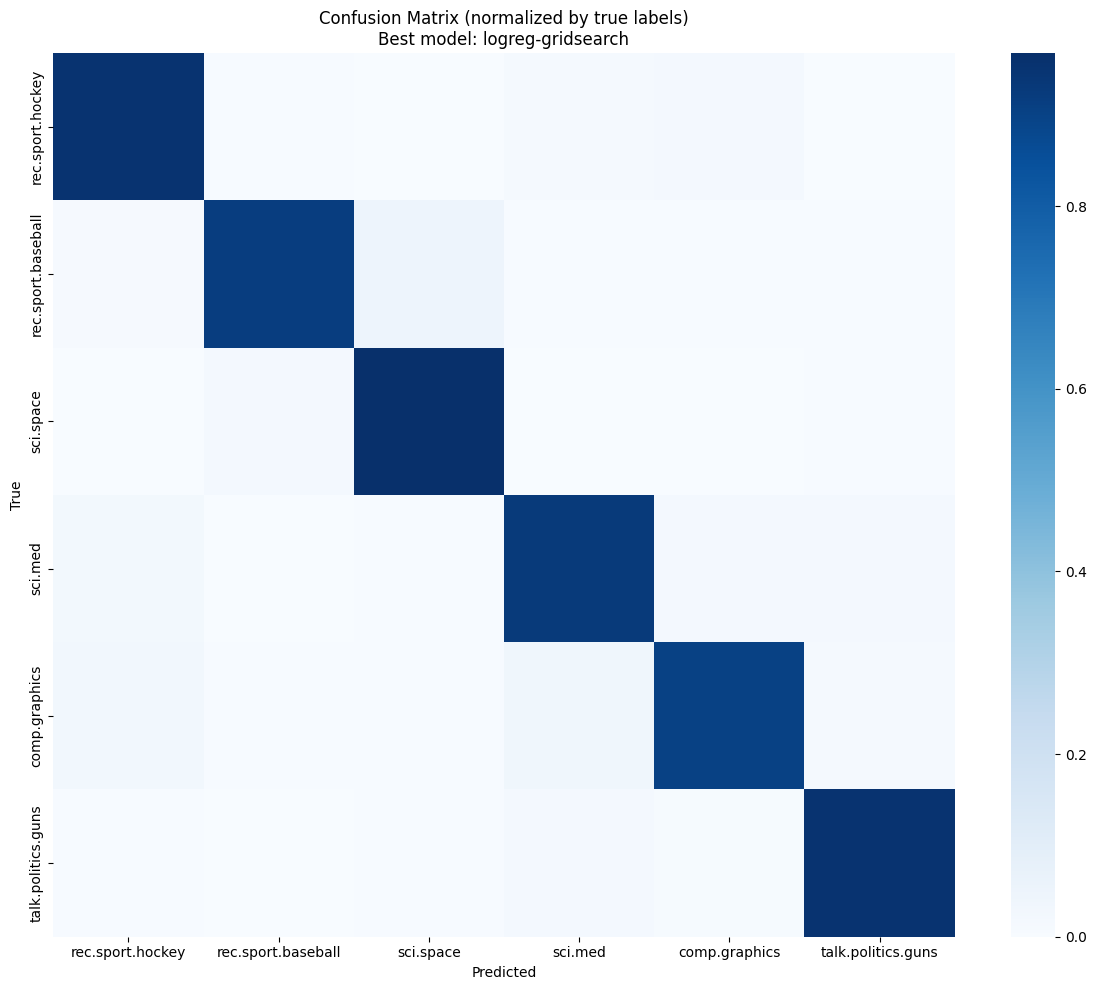


Топ-3 пары классов, которые модель путает чаще всего (нормализованная доля ошибок):
  rec.sport.baseball -> sci.space: 0.053 (доля ошибочных предсказаний для класса rec.sport.baseball)
  comp.graphics -> sci.med: 0.038 (доля ошибочных предсказаний для класса comp.graphics)
  comp.graphics -> rec.sport.hockey: 0.030 (доля ошибочных предсказаний для класса comp.graphics)

Примеры ошибочных предсказаний для каждой пары:

--- Пара 1: Истинный класс = 'rec.sport.baseball', предсказанный = 'sci.space' ---

  Текст документа (начало):
    From: sas@cbnewsg.cb.att.com (s.a.sullivan)
Subject: Re: Let's play the name game!
Organization: AT&T
Distribution: na
Lines: 13

In article <1993Apr20.035607.26095@newshub.ariel.yorku.ca> cs902043@ariel.yorku.ca (SHAWN LUDDINGTON) writes:
>How about changing team names!
>Post your choices!
>
>Here I'll start:
>How about the 
>Baltimore Baseblazers
>San Francisco Quakes
>Pittsburgh Sellouts>
>Shawn - Go Rangers!!!!!!!!!!!!!!!!!!!
>



  Истинная метка: rec.

2026/06/23 10:06:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'news-classifier' already exists. Creating a new version of this model...
2026/06/23 10:06:31 WARNING mlflow.tracking._model_registry.fluent: Run with id 7267ee33122e477286b948da3cb22541 has no artifacts at artifact path 'model', registering model based on models:/m-02b744a5e42a4af48dd26d2dac352287 instead


Модель зарегистрирована: news-classifier версия 3
Модель переведена в стадию Production
Модель загружена из Production

Проверка предсказаний на коротких текстах:
Текст: The goal was scored on a breakaway in the final mi... -> sci.space
Текст: The pitcher threw a curveball and struck out the b... -> rec.sport.baseball
Текст: NASA's new telescope will study exoplanets and the... -> comp.graphics
Текст: The clinical trial showed a significant reduction ... -> sci.med
Текст: The new GPU supports real-time ray tracing and AI ... -> rec.sport.hockey
Текст: The bill proposes stricter background checks for f... -> talk.politics.guns


Created version '3' of model 'news-classifier'.
/tmp/ipykernel_7494/3210551749.py:135: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import mlflow
from mlflow.tracking import MlflowClient
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

categories = [
    'rec.sport.hockey', 'rec.sport.baseball',
    'sci.space', 'sci.med',
    'comp.graphics', 'talk.politics.guns',
]

print("\nРезультаты запусков:")
for name, res in run_results.items():
    print(f"  {name}: f1_macro = {res['f1_macro']:.4f}")

best_run_name = max(run_results, key=lambda k: run_results[k]['f1_macro'])
best_f1 = run_results[best_run_name]['f1_macro']
print(f"\nЛучшая модель: {best_run_name} (f1_macro = {best_f1:.4f})")

if best_run_name == "tfidf-logreg":
    model = LogisticRegression(max_iter=1000, C=5)
    model.fit(X_train_tfidf, y_train)
    vec = vectorizer
    X_test_used = X_test_tfidf
elif best_run_name == "catboost-multiclass":
    model = CatBoostClassifier(loss_function='MultiClass', iterations=500,
                               learning_rate=0.1, depth=6, random_seed=42, verbose=False)
    model.fit(X_train_tfidf, y_train)
    vec = vectorizer
    X_test_used = X_test_tfidf
else:
    model = best_model
    vec = best_vec
    X_test_used = vec.transform(x_test)

y_pred_best = model.predict(X_test_used)

cm = confusion_matrix(y_test, y_pred_best, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='.2f', cmap='Blues',
            xticklabels=categories,
            yticklabels=categories)
plt.title(f'Confusion Matrix (normalized by true labels)\nBest model: {best_run_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

np.fill_diagonal(cm, 0)
flat_idx = np.argsort(cm, axis=None)[::-1]
top_pairs = []
for idx in flat_idx:
    i = idx // cm.shape[1]
    j = idx % cm.shape[1]
    if i != j:
        top_pairs.append((i, j, cm[i, j]))
    if len(top_pairs) == 3:
        break

print("\nТоп-3 пары классов, которые модель путает чаще всего (нормализованная доля ошибок):")
for i, j, val in top_pairs:
    true_name = categories[i]
    pred_name = categories[j]
    print(f"  {true_name} -> {pred_name}: {val:.3f} (доля ошибочных предсказаний для класса {true_name})")

print("\nПримеры ошибочных предсказаний для каждой пары:")
for idx_pair, (i, j, _) in enumerate(top_pairs):
    print(f"\n--- Пара {idx_pair+1}: Истинный класс = '{categories[i]}', "
          f"предсказанный = '{categories[j]}' ---")
    error_indices = np.where((y_test == i) & (y_pred_best == j))[0]
    sample_indices = error_indices[:3]
    if len(sample_indices) == 0:
        print("  Нет примеров (возможно, эта пара встретилась только в кросс-валидации?)")
        continue
    for idx in sample_indices:
        text = x_test[idx]
        snippet = text[:500] + ("..." if len(text) > 500 else "")
        print(f"\n  Текст документа (начало):\n    {snippet}")
        print(f"  Истинная метка: {categories[y_test[idx]]}")
        print(f"  Предсказанная: {categories[y_pred_best[idx]]}")
        print("  " + "-"*60)

client = MlflowClient()

if 'run_id' in run_results[best_run_name]:
    best_run_id = run_results[best_run_name]['run_id']
    model_uri = f"runs:/{best_run_id}/model"
    try:
        registered_model = mlflow.register_model(model_uri, "news-classifier")
        print(f"Модель зарегистрирована: {registered_model.name} версия {registered_model.version}")
    except Exception as e:
        print(f"Ошибка регистрации: {e}. Переобучаем и регистрируем заново...")
        model_uri = None
else:
    print("run_id отсутствует, переобучаем модель и регистрируем заново...")
    model_uri = None

if model_uri is None:
    with mlflow.start_run(run_name="best-model-registration") as run:
        if best_run_name == "tfidf-logreg":
            model = LogisticRegression(max_iter=1000, C=5)
            model.fit(X_train_tfidf, y_train)
            vec = vectorizer
            X_test_used = X_test_tfidf
        elif best_run_name == "catboost-multiclass":
            model = CatBoostClassifier(loss_function='MultiClass', iterations=500,
                                       learning_rate=0.1, depth=6, random_seed=42, verbose=False)
            model.fit(X_train_tfidf, y_train)
            vec = vectorizer
            X_test_used = X_test_tfidf
        else:
            model = best_model
            vec = best_vec
            X_test_used = vec.transform(x_test)
        y_pred = model.predict(X_test_used)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        if best_run_name.startswith("tfidf") or best_run_name == "logreg-gridsearch":
            mlflow.sklearn.log_model(model, "model")
        else:
            from mlflow.catboost import log_model
            log_model(model, "model")
        model_uri = f"runs:/{run.info.run_id}/model"
        registered_model = mlflow.register_model(model_uri, "news-classifier")
        print(f"Модель зарегистрирована: {registered_model.name} версия {registered_model.version}")

client.transition_model_version_stage(
    name="news-classifier",
    version=registered_model.version,
    stage="Production"
)
print("Модель переведена в стадию Production")

model_production = mlflow.sklearn.load_model("models:/news-classifier/Production")
print("Модель загружена из Production")

sample_texts = [
    "The goal was scored on a breakaway in the final minute of the third period.",
    "The pitcher threw a curveball and struck out the batter to end the inning.",
    "NASA's new telescope will study exoplanets and their atmospheres.",
    "The clinical trial showed a significant reduction in tumor size.",
    "The new GPU supports real-time ray tracing and AI upscaling.",
    "The bill proposes stricter background checks for firearm purchases."
]
print("\nПроверка предсказаний на коротких текстах:")
for text in sample_texts:
    vec_text = vec.transform([text])
    pred = model_production.predict(vec_text)[0]
    print(f"Текст: {text[:50]}... -> {categories[pred]}")

**Пары с наибольшим числом ошибок и объяснение:** *(запишите)*

---

## Задание 5 — MLflow Model Registry

1. Найдите лучший run по `f1_macro`
2. Зарегистрируйте модель под именем `news-classifier`
3. Переведите в стадию `Production`
4. Загрузите и проверьте предсказание на коротком тексте по каждой из выбранных категорий

In [ ]:
import mlflow
from mlflow.tracking import MlflowClient

best_run_name = max(run_results, key=lambda k: run_results[k]['f1_macro'])
print(f"Лучший run: {best_run_name} (f1_macro = {run_results[best_run_name]['f1_macro']:.4f})")

client = MlflowClient()

if 'run_id' in run_results[best_run_name]:
    best_run_id = run_results[best_run_name]['run_id']
    model_uri = f"runs:/{best_run_id}/model"
    try:
        registered_model = mlflow.register_model(model_uri, "news-classifier")
        print(f"Модель зарегистрирована: {registered_model.name} {registered_model.version}")
    except Exception as e:
        print(f"Ошибка регистрации: {e}. Переобучаем и регистрируем заново...")
        model_uri = None
else:
    print("run_id отсутствует, переобучаем модель и регистрируем заново...")
    model_uri = None

if model_uri is None:
    with mlflow.start_run(run_name="best-model-registration") as run:
        if best_run_name == "tfidf-logreg":
            model = LogisticRegression(max_iter=1000, C=5)
            model.fit(X_train_tfidf, y_train)
            vec = vectorizer
            X_test_used = X_test_tfidf
        elif best_run_name == "catboost-multiclass":
            model = CatBoostClassifier(loss_function='MultiClass', iterations=500,
                                       learning_rate=0.1, depth=6, random_seed=42, verbose=False)
            model.fit(X_train_tfidf, y_train)
            vec = vectorizer
            X_test_used = X_test_tfidf
        else:
            model = best_model
            vec = best_vec
            X_test_used = vec.transform(x_test)
        y_pred = model.predict(X_test_used)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        if best_run_name.startswith("tfidf") or best_run_name == "logreg-gridsearch":
            mlflow.sklearn.log_model(model, "model")
        else:
            from mlflow.catboost import log_model
            log_model(model, "model")
        model_uri = f"runs:/{run.info.run_id}/model"
        registered_model = mlflow.register_model(model_uri, "news-classifier")
        print(f"Модель зарегистрирована: {registered_model.name} v{registered_model.version}")

client.transition_model_version_stage(
    name="news-classifier",
    version=registered_model.version,
    stage="Production"
)
print("Модель переведена в стадию Production")

model_production = mlflow.sklearn.load_model("models:/news-classifier/Production")
print("Модель загружена из Production")

sample_texts = [
    "The goal was scored in the final minute of the third period.",
    "The pitcher threw a fastball and struck out the batter.",
    "NASA launched a new satellite to study the solar wind.",
    "The new drug shows promise in treating cancer patients.",
    "The latest graphics card supports real-time ray tracing.",
    "Gun control laws are being debated in the senate."
]
categories = train_data.target_names
print("\nПроверка предсказаний на коротких текстах:")
for text in sample_texts:
    vec_text = vec.transform([text])
    pred = model_production.predict(vec_text)[0]
    print(f"Текст: {text[:50]}... -> {categories[pred]}")

Лучший run: logreg-gridsearch (f1_macro = 0.9372)
run_id отсутствует, переобучаем модель и регистрируем заново...


2026/06/23 10:07:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'news-classifier' already exists. Creating a new version of this model...
2026/06/23 10:08:03 WARNING mlflow.tracking._model_registry.fluent: Run with id d7afac5dc4a247869462633115a615ea has no artifacts at artifact path 'model', registering model based on models:/m-31133d693be0475b87f586c3aa15d8eb instead


Модель зарегистрирована: news-classifier v5
Модель переведена в стадию Production
Модель загружена из Production

Проверка предсказаний на коротких текстах:
Текст: The goal was scored in the final minute of the thi... -> rec.sport.hockey
Текст: The pitcher threw a fastball and struck out the ba... -> rec.sport.baseball
Текст: NASA launched a new satellite to study the solar w... -> sci.space
Текст: The new drug shows promise in treating cancer pati... -> sci.med
Текст: The latest graphics card supports real-time ray tr... -> comp.graphics
Текст: Gun control laws are being debated in the senate.... -> talk.politics.guns


Created version '5' of model 'news-classifier'.
/tmp/ipykernel_7494/1350706931.py:53: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


---

## Задание 6 — FastAPI-сервис

Создайте `app/main.py`:

**`GET /health`** → `{"status": "ok", "num_classes": 6}`

**`POST /classify`** принимает `{"text": "..."}` (минимум 20 символов), возвращает:
```json
{"category": "sci.space", "confidence": 0.92, "top3": [{"category": "...", "probability": 0.92}, ...]}
```

Напишите тесты (≥ 8): health с num_classes, classify для каждой категории, пустой текст (→ 422), очень короткий текст.

---

## Задание 7 — Docker и CI/CD

**`Dockerfile`** — образ на `python:3.11-slim`, запускает `uvicorn app.main:app`.

**`.github/workflows/ci.yml`** — pytest → Docker build → push в GHCR при push в `main`.

---

## Чеклист сдачи

### Обязательный минимум (Pass)
- [ ] Датасет загружен с `remove=('headers', 'footers', 'quotes')`
- [ ] EDA: документов на класс, длины текстов, топ-слова
- [ ] MLflow: 3 run-а с метриками (`accuracy`, `f1_macro`)
- [ ] Лучший run → MLflow Registry → Production
- [ ] FastAPI: `GET /health` (num_classes) + `POST /classify` (top3)
- [ ] pytest: ≥ 8 тестов
- [ ] Dockerfile + GitHub Actions CI

### На хорошую оценку (Good)
- [ ] Accuracy ≥ 0.80, F1-macro ≥ 0.80
- [ ] Confusion matrix с нормализацией
- [ ] F1 per class таблица
- [ ] 5-fold stratified CV для надёжной оценки

### Дополнительно (Excellent)
- [ ] Streamlit: поле ввода статьи → топ-3 категории с bar chart
- [ ] Анализ уверенных ошибок (confidence > 0.9, но неправильная категория)
- [ ] Сравнение LogReg vs LinearSVC vs CatBoost